In [1]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

Found cached dataset csv (C:/Users/theim/.cache/huggingface/datasets/lukebarousse___csv/lukebarousse--data_jobs-20095235c13fb98d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1)


  0%|          | 0/1 [00:00<?, ?it/s]

In [3]:
# Only et the US Data Analyst job postings
df_US_DA = df[
    (df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')
].copy()

# Remove NaN values frrom column for plotting
df_US_DA = df_US_DA.dropna(subset=['salary_year_avg'])

<Axes: >

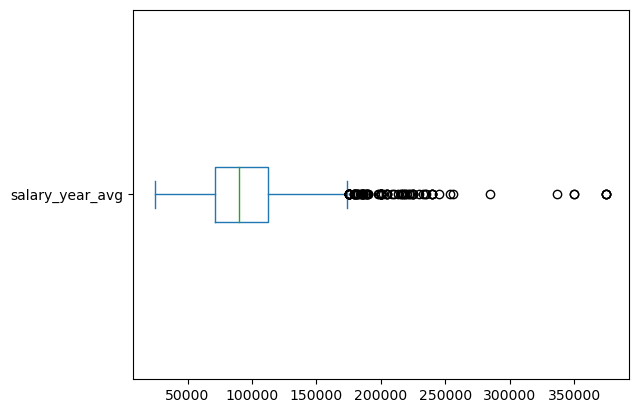

In [ ]:
df_US_DA['salary_year_avg'].plot(kind='box', vert=False)

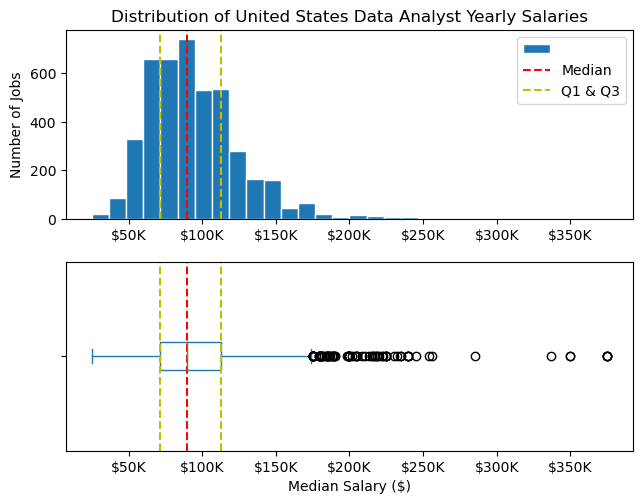

In [26]:
fig, ax = plt.subplots(2, 1)
fig.tight_layout(h_pad=1)

# Histogram
df_US_DA['salary_year_avg'].plot(
    kind='hist', 
    ax=ax[0], 
    bins=30, 
    edgecolor='white'
)

ax[0].set_title('Distribution of United States Data Analyst Yearly Salaries')
ax[0].set_xlabel('')
ax[0].set_ylabel('Number of Jobs')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(
    lambda  x, pos: f'${int(x/1000)}K'
))
ax[0].axvline(df_US_DA['salary_year_avg'].median(), color='r', linestyle='--')
ax[0].axvline(df_US_DA['salary_year_avg'].quantile(0.25), color='y', linestyle='--')
ax[0].axvline(df_US_DA['salary_year_avg'].quantile(0.75), color='y', linestyle='--')
ax[0].legend(['', 'Median', 'Q1 & Q3'])

# Box Plot Chart
df_US_DA['salary_year_avg'].plot(kind='box', ax=ax[1], vert=False)

ax[1].set_yticklabels('')
ax[1].set_xlabel('Median Salary ($)')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(
    lambda  x, pos: f'${int(x/1000)}K'
))
ax[1].axvline(df_US_DA['salary_year_avg'].median(), color='r', linestyle='--')
ax[1].axvline(df_US_DA['salary_year_avg'].quantile(0.25), color='y', linestyle='--')
ax[1].axvline(df_US_DA['salary_year_avg'].quantile(0.75), color='y', linestyle='--')

plt.show()

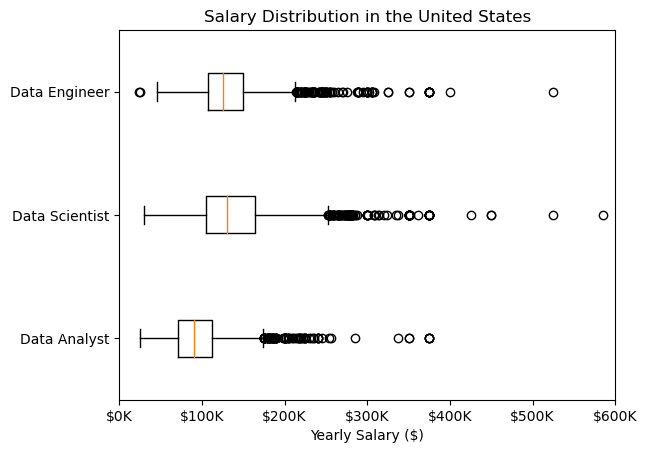

In [45]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

# Filter for only data jobs in US
df_US = df[
    (df['job_country'] == 'United States') & (df['job_title_short'].isin(job_titles))
].copy()

# Remove NaN salaries
df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [
    df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles
]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($)')
plt.xlim(0, 600000)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda  x, pos: f'${int(x/1000)}K'
    )
)
plt.show()

In [40]:
job_list[0]

109        89000.0
180        90250.0
410       133285.0
988        62623.0
1413       71300.0
            ...   
782637     70000.0
782798    111175.0
783588    125000.0
783866    115000.0
784882     87500.0
Name: salary_year_avg, Length: 4350, dtype: float64